# Classic Jablonski model

In [21]:
import sys
sys.path.append(r"C:\Users\vie43sq\OneDrive - Universität Würzburg\GitHub\MarkovModels")

import numpy as np
import matplotlib.pyplot as plt
import src.fluorophore_systems as fs
import src.custom_plot as cp
import src.large_scale as ls
import src.figures as fi
from IPython.display import HTML

%load_ext autoreload
%autoreload 2

### Define the state transition rates

In [106]:
rate_dict = dict(k_S0_S1=1e15,  # excitation
                 k_S1_S0=1e8,  # emission
                 k_S1_T1=1e6,  # intersystem crossing
                 k_T1_S0=1e5,  # phosphorescence
                 k_S1_B=1e3,  # bleaching
                 k_T1_R=1e4,  # reduction
                 k_R_S0=0.5e0)  # oxidation

### Initialize system

In [110]:
system = fs.JablonskiModel(number=3, distances=1, photon_collection=0.2, rates=rate_dict)

### Simulate the Markov process

In [111]:
time_series, time_step_series, state_series = system.simulate(n_steps=100000, seed=99, base="cy")

### Receive emission events

In [112]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="5ms")

### Unique states and their occupation times
Example: S0_S1 and S1_S0 are united

In [113]:
unique_series_converted, unique_states, occupation_time_mean = system.process()

### Fluoresecence correlation (Autocorrelation)

In [69]:
auto_correlation = system.fcs()

## Visualization

In [7]:
system.animate(index_range=100, saveas="classic_jablonski.mp4")

In [10]:
HTML("""
<div align="middle">
<video width="80%" controls>
      <source src="jablonski.mp4" type="video/mp4">
</video></div>""")

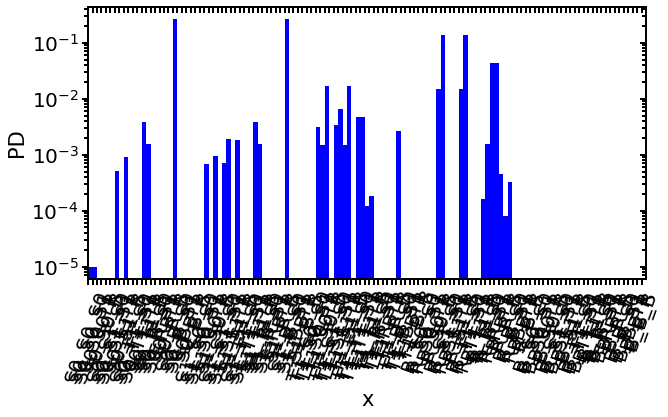

In [51]:
fig, ax = fi.FigureCollection(system).state_population(use_unique=False)

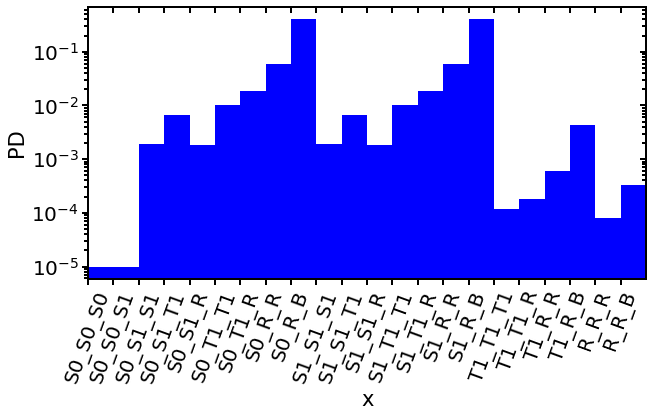

In [50]:
fig, ax = fi.FigureCollection(system).state_population()

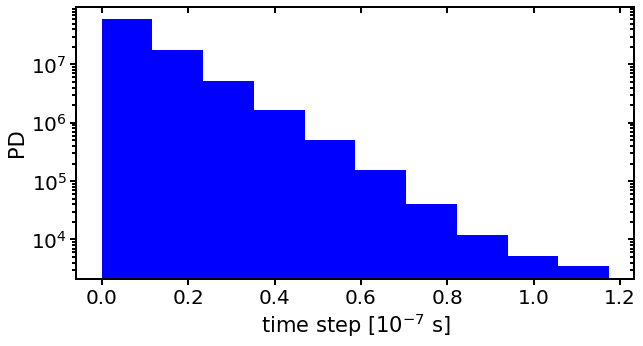

In [54]:
fig, ax = fi.FigureCollection(system).time_steps(xlabel="time step [$10^{-7}$ s]", tick_style_x="sci")

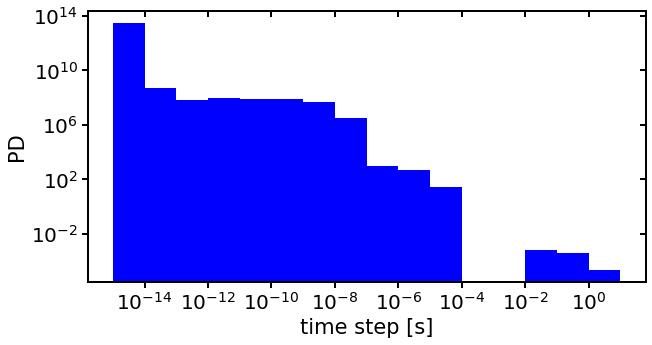

In [58]:
fig, ax = fi.FigureCollection(system).time_steps(only_emitting_transitions=False, 
                                                 xlabel="time step [s]", xscale="log",
                                                 bins=10**(np.arange(-15, 2, dtype=np.float64)))

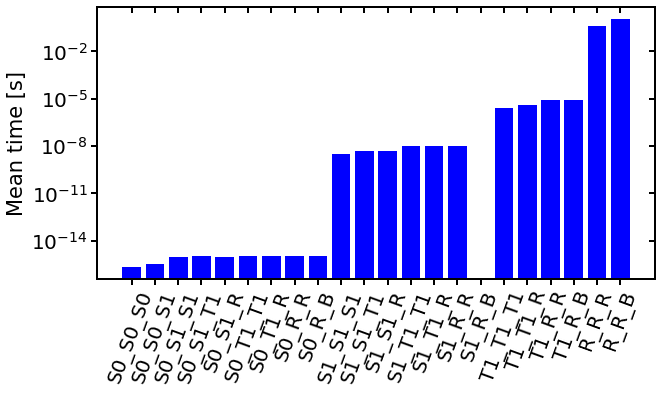

In [60]:
fig, ax = fi.FigureCollection(system).occupation_time()

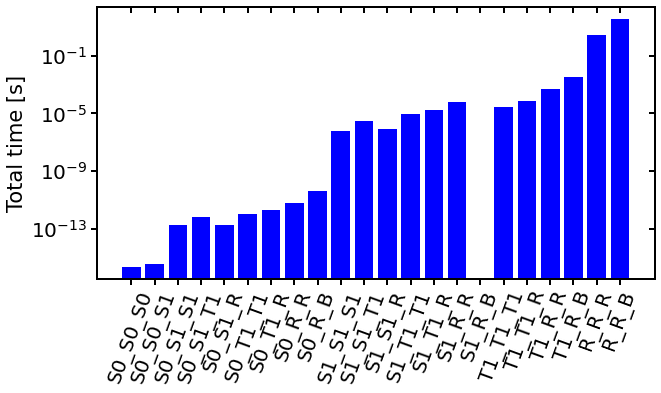

In [61]:
fig, ax = fi.FigureCollection(system).occupation_time(total=True)

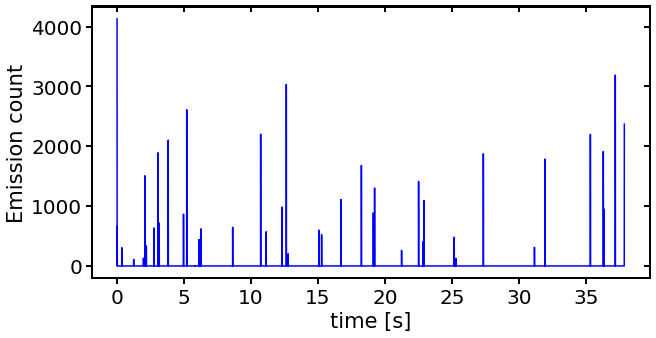

In [123]:
fig, ax = fi.FigureCollection(system).emission_events()

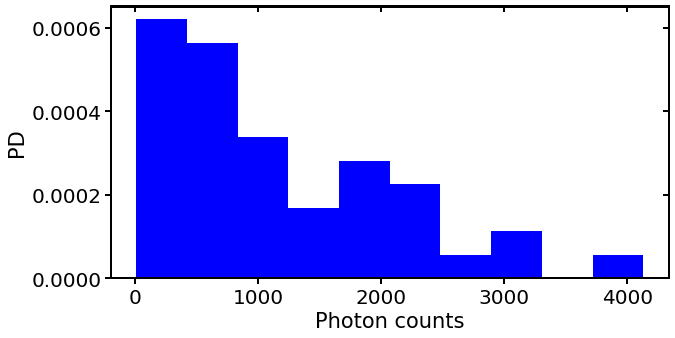

In [63]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False)

In [114]:
auto_correlation = system.fcs(log=False)

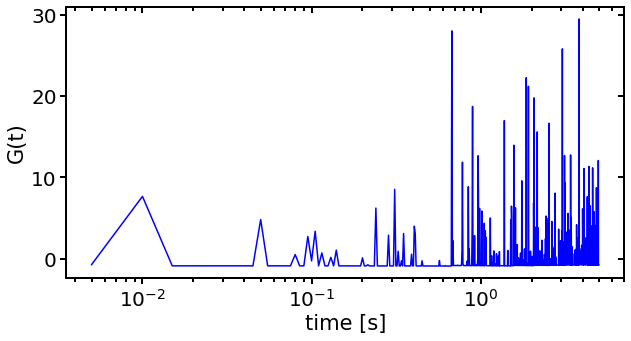

In [115]:
fig, ax = fi.FigureCollection(system).fcs(log=False)

In [116]:
auto_correlation = system.fcs()

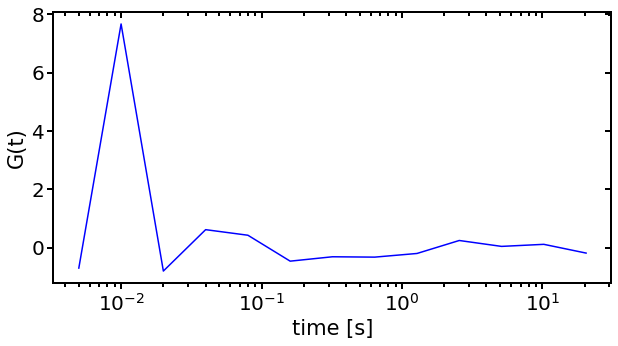

In [117]:
fig, ax = fi.FigureCollection(system).fcs()

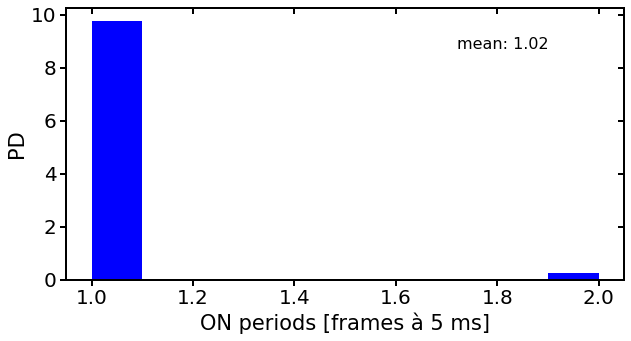

In [119]:
fig, ax = fi.FigureCollection(system).on_off()

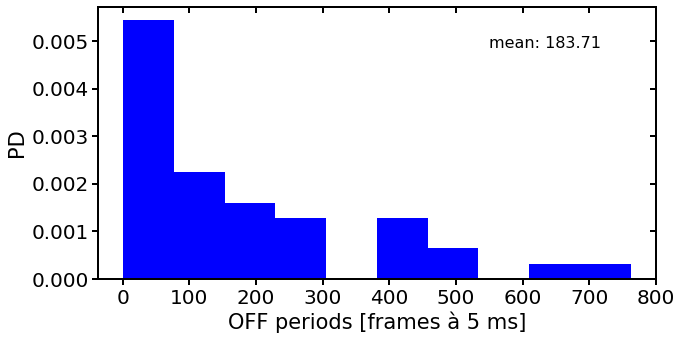

In [121]:
fig, ax = fi.FigureCollection(system).on_off(on=False)

## Multiple runs

In [39]:
class_args = dict(number=3, distances=1, photon_collection=0.2, rates=rate_dict)
simulate_args = dict(n_steps=100000, base="cy")
emitting_args = dict(unit="s", resample="5ms")

In [40]:
%%time
systems = ls.multiple_simulations(10, "Jablonski", class_args, simulate_args, emitting_args, 100)

CPU times: total: 22.9 s
Wall time: 22.9 s


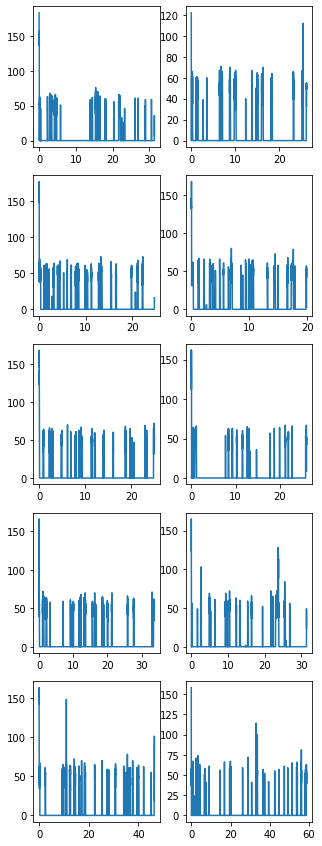

In [236]:
fig, axes = plt.subplots(-(len(systems)//-2), 2, figsize=(5, -(len(systems)//-2)*3))
for ax, sys in zip(axes.ravel(), systems):
    x = sys.pandas_series.index
    y = sys.pandas_series.values
    ax.plot(x, y)